# CMI with $S$: toric plaquette ring



Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce


We now replace the GHZ state by the ground-state density matrix of a $1\times N$ ring of toric-code plaquettes.

The physical qubits are the shared edges between neighboring plaquettes. With periodic boundary conditions, label them

\[
e_i,\qquad i=0,\dots,N-1.
\]

Plaquette $p_i$ touches the two shared edges $e_{i-1}$ and $e_i$, so the effective plaquette stabilizer on this ring is

\[
B_i = Z_{i-1}Z_i,
\]

with indices understood modulo $N$. The plaquette-only ground space is the simultaneous $+1$ eigenspace of all $B_i$:

\[
B_i\rho_{\rm gs}=\rho_{\rm gs},\qquad i=0,\dots,N-1.
\]

The normalized ground-state density matrix is the stabilizer projector

\[
\rho_{\rm gs}=\frac{1}{2^k}\prod_{i=0}^{N-1}\frac{I+B_i}{2}.
\]

For this simplified shared-edge ring, one stabilizer is dependent, so $k=1$. Equivalently, the ground space is spanned by
$|00\cdots0\rangle$ and $|11\cdots1\rangle$, and the maximally mixed ground-state density matrix is

\[
\rho_{\rm gs}=\frac{1}{2}
\left(|00\cdots0\rangle\langle 00\cdots0|
+
|11\cdots1\rangle\langle 11\cdots1|\right).
\]

If you want a pure logical ground state instead, you can use the coherent state

\[
|\psi_+\rangle=\frac{|00\cdots0\rangle+|11\cdots1\rangle}{\sqrt 2}.
\]




In [2]:
# Defining rho_gs for the 1 x N plaquette ring

# -------------------------
# Tensor product helper
# -------------------------
def kron_power(v, N):
    """Compute v ⊗ v ⊗ ... ⊗ v (N times)."""
    return reduce(np.kron, [v] * N)

# -------------------------
# Parameters
# -------------------------
N = 12  # number of shared-edge qubits = number of plaquettes in the ring

# -------------------------
# Basis states |0> and |1>
# -------------------------
ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)

# -------------------------
# Product states |0...0> and |1...1>
# -------------------------
ket_0N = kron_power(ket_0, N)
ket_1N = kron_power(ket_1, N)

# -------------------------
# Plaquette-ring ground-state density matrix
# This is the normalized projector onto the +1 eigenspace of B_i = Z_{i-1} Z_i.
# -------------------------
rho_gs = 0.5 * (np.outer(ket_0N, ket_0N.conj()) + np.outer(ket_1N, ket_1N.conj()))

# Optional pure logical ground state, analogous in form to GHZ.
ket_logical_plus = (ket_0N + ket_1N) / np.sqrt(2)
rho_logical_plus = np.outer(ket_logical_plus, ket_logical_plus.conj())

print("Toric plaquette-ring ground-state density matrix shape:", rho_gs.shape)
print("Trace:", np.trace(rho_gs))
print("Nonzero eigenvalues:", np.linalg.eigvalsh(rho_gs)[np.linalg.eigvalsh(rho_gs) > 1e-12])


Toric plaquette-ring ground-state density matrix shape: (4096, 4096)
Trace: (1+0j)
Nonzero eigenvalues: [0.5 0.5]


Next, define the bit-flip noise channel on the shared edges between plaquettes:

\[
\mathcal{E}^{i}_p(\rho)=(1-p)\rho+pX_i\rho X_i.
\]

The full channel acts independently on all shared-edge qubits:

\[
\mathcal{E}_p(\rho)=\prod_{i=0}^{N-1}\mathcal{E}^{i}_p(\rho).
\]

A bit flip on edge $e_i$ anticommutes with the two neighboring plaquette stabilizers,

\[
X_i B_i X_i=-B_i,
\qquad
X_i B_{i+1}X_i=-B_{i+1},
\]

so it creates a pair of neighboring plaquette defects.



In [3]:
# Defining the bit-flip noise channel on shared-edge qubits

Pauli_X = np.array([[0, 1], [1, 0]], dtype=complex)
I = np.eye(2, dtype=complex)


def local_operator(op, i, N):
    """
    Build operator acting on i-th qubit (0-based index) in an N-qubit system.
    This is useful for small checks, but the channel below uses a faster permutation method.
    """
    ops = [I] * N
    ops[i] = op
    return reduce(np.kron, ops)


def bit_flip_indices(i, N):
    """
    Return the computational-basis permutation corresponding to X_i.

    The convention here matches the tensor-product ordering used by np.kron:
    qubit 0 is the leftmost / most significant qubit.
    """
    dim = 2 ** N
    mask = 1 << (N - 1 - i)
    return np.arange(dim) ^ mask


def conjugate_by_X_i(rho, i, N):
    """Compute X_i rho X_i without explicitly constructing the 2^N x 2^N operator."""
    perm = bit_flip_indices(i, N)
    return rho[np.ix_(perm, perm)]


def bit_flip_channel(rho, p, i, N):
    """
    Apply a bit-flip channel to shared edge/qubit i.
    """
    return (1 - p) * rho + p * conjugate_by_X_i(rho, i, N)



In [4]:
# Test: apply channel on one shared edge
p_test = 0.1
rho_out = bit_flip_channel(rho_gs, p_test, i=0, N=N)

print("Trace after one local channel:", np.trace(rho_out))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_out)))



Trace after one local channel: (1+0j)
Min eigenvalue: 0.0


In [5]:
# Repeated application of bit-flip channel on every shared edge

def noise_channel(rho_0, p, N):
    """
    Apply independent bit-flip noise to all shared-edge qubits of the plaquette ring.
    """
    rho = rho_0.copy()
    for i in range(N):
        rho = bit_flip_channel(rho, p, i, N)
    return rho



In [6]:
# Test: apply full channel to rho_gs
rho_out_2 = noise_channel(rho_gs, p_test, N=N)

print("Trace after full channel:", np.trace(rho_out_2))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_out_2)))



Trace after full channel: (1.0000000000000009+0j)
Min eigenvalue: 5.314410000000002e-07


In [7]:
#np.savetxt('rho_out_2 .txt', rho_out_2 , fmt='%f', delimiter='\t')


Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 


In [ ]:
#Possible fix: calculating log2 straingth away?


In [8]:
#Calculating von Neumann entropy
def von_neumann_entropy(rho, base=2):
    """
    Compute von Neumann entropy S(rho) = -Tr(rho log rho)
    base = np.e gives natural log, base=2 gives bits
    """
    eigvals = np.linalg.eigvalsh(rho)

    # clip numerical errors
    #eigvals = np.clip(eigvals, 0, 1)

    # normalize (important!)
    #eigvals = eigvals / np.sum(eigvals)

    # remove zeros safely
    eigvals = eigvals[eigvals > 1e-12]

    S = -np.sum(eigvals * np.log2(eigvals))

    #if base == 2:
        #S /= np.log(2)

    return S


In [9]:
#Test

S = von_neumann_entropy(rho_out)
print("Von Neumann entropy:", S)


Von Neumann entropy: 1.4689955935892813


In [10]:
def partial_trace(rho, keep, N):
    """
    Correct partial trace over all qubits not listed in keep.

    rho:
        Full density matrix of shape (2^N, 2^N)

    keep:
        List of qubit indices to keep, using Python 0-based indexing.

    N:
        Total number of qubits.

    Returns:
        Reduced density matrix on the qubits in keep.
    """

    keep = sorted(keep)

    # Qubits to trace out
    trace_out = [q for q in range(N) if q not in keep]

    # Reshape rho into tensor form:
    # rho[i1, i2, ..., iN, j1, j2, ..., jN]
    rho_tensor = rho.reshape([2] * N + [2] * N)

    # Trace out qubits from largest index to smallest.
    # This avoids axis-shifting problems after each trace.
    current_N = N

    for q in sorted(trace_out, reverse=True):
        rho_tensor = np.trace(
            rho_tensor,
            axis1=q,
            axis2=q + current_N,
        )
        current_N -= 1

    dim_keep = 2 ** len(keep)

    return rho_tensor.reshape(dim_keep, dim_keep)


In [11]:
#Function to compute reduced density matrix

def partial_trace0(rho, keep, N):
    """
    Partial trace over all subsystems NOT in 'keep'.

    Parameters:
    - rho: full density matrix (2^N x 2^N)
    - keep: list of subsystem indices to keep (e.g. [0,2])
    - N: number of qubits

    Returns:
    - reduced density matrix
    """

    dims = [2] * N

    rho_t = rho.reshape(dims + dims)

    keep = sorted(keep)

    # indices for full system
    all_idx = list(range(N))

    trace_idx = [i for i in all_idx if i not in keep]

    # build einsum string dynamically
    import string

    letters = string.ascii_lowercase + string.ascii_uppercase

    # assign indices for bra and ket spaces
    inds = letters[:N] + letters[N:2*N]

    # build contraction
    keep_bra = [inds[i] for i in keep]
    keep_ket = [inds[i + N] for i in keep]

    einsum_str = ''.join(inds) + '->' + ''.join(keep_bra + keep_ket)

    return np.einsum(einsum_str, rho_t)


Partition into subregions $A$, $B$, and $C$.

Here the subsystem labels are shared-edge qubits around the plaquette ring. The choice below keeps the same one-dimensional annulus-like structure as in the GHZ notebook: $A$ is a contiguous block, $B$ consists of the two buffer regions adjacent to $A$, and $C$ is the rest.



In [12]:
#partition into subregions A,B,C

A = [0,1,2,3]

B = [4,5,10,11]

C = [6,7,8,9]



In [13]:
def CMI(p, rho_0, A, B, C, N):
    """
    Compute S(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC)
    after applying shared-edge bit-flip noise with probability p.
    """

    rho = noise_channel(rho_0, p, N)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N))
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N))
    S_B = von_neumann_entropy(partial_trace(rho, B, N))
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N))

    return S_AB + S_BC - S_B - S_ABC



In [14]:
def CMI0(p,rho_0, A, B, C, N):


    rho = noise_channel(rho_0, p, N)

    S_AB = von_neumann_entropy(partial_trace(rho, A + B, N), base=2)
    print(f'S_AB={S_AB}')
    S_BC = von_neumann_entropy(partial_trace(rho, B + C, N), base=2)
    print(f'S_BC={S_BC}')
    S_B  = von_neumann_entropy(partial_trace(rho, B, N), base=2)
    print(f'S_B={S_B}')
    S_ABC = von_neumann_entropy(rho, base=2)
    print(f'S_ABC={S_ABC}')

    print(f'CMI={S_AB + S_BC - S_B - S_ABC}')

    return S_AB + S_BC - S_B - S_ABC


In [15]:
print(A, B, C)
print(rho_out.shape)
print(N)


[0, 1, 2, 3] [4, 5, 10, 11] [6, 7, 8, 9]
(4096, 4096)
12


In [16]:
#test

cmi_test = CMI(p_test,rho_gs,A=A,B=B,C=C,N=N)

print(cmi_test)


0.06274853437675887


In [ ]:
cmi_test2 = CMI(0.5,rho_gs,A=A,B=B,C=C,N=N)

print(cmi_test2)


In [17]:
#Array of different noise rates

p_array = np.linspace(0.001,0.999,20)
cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_gs,A=A,B=B,C=C,N=N)


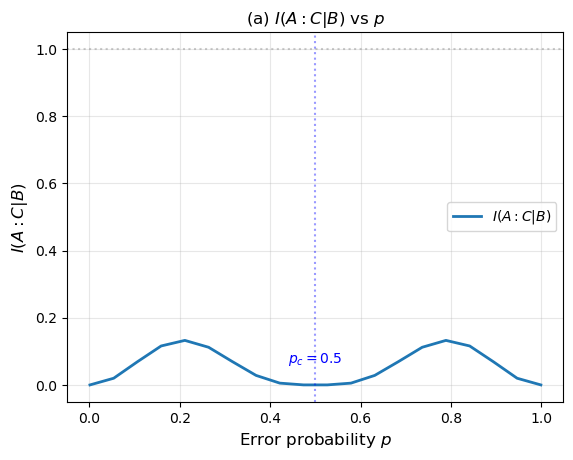

In [18]:
fig, ax = plt.subplots()

ax.plot(p_array, cmi_array,lw=2, label=r'$I(A{:}C|B)$')
#ax.plot(p_values, mi_AC_values, 'r--', lw=1.5, alpha=0.7, label=r'$I(A{:}C)$')
ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
ax.axvline(0.5, color='blue', ls=':', alpha=0.4)
ax.set_xlabel(r'Error probability $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C|B)$ ', fontsize=12)
ax.set_title(r'(a) $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate(r'$p_c = 0.5$', xy=(0.5, 0.05), fontsize=10, color='blue',
            ha='center', va='bottom')

plt.show()


Comment: why CMI values might be a bit inflated, especially compared to the earloer results, calculated with H.


In [19]:
#check

rho_test = noise_channel(rho_gs, p_test, N)

print("Trace:", np.trace(rho_test))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_test)))


Trace: (1.0000000000000009+0j)
Min eigenvalue: 5.314410000000002e-07


In [20]:
print("Trace:", np.trace(rho_gs))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_gs)))


Trace: (1+0j)
Min eigenvalue: 0.0


In [ ]:
#Array of different noise rates

p_array = np.linspace(0.001,0.999,40)
cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_gs,A=A,B=B,C=C,N=N)
